In [1]:
import os

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["hadoop.home.dir"] = r"C:\hadoop"
os.environ["PATH"] += r";C:\hadoop\bin"

print(os.environ.get("HADOOP_HOME"))
print(os.environ.get("hadoop.home.dir"))
print(os.path.exists(r"C:\hadoop\bin\winutils.exe"))

C:\hadoop
C:\hadoop
True


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("UCIN_Prediccion") \
    .getOrCreate()

In [3]:
#cargar datos
df = spark.read.csv(
   "natalidad2022us.csv",
    #"natalidad_1mb.csv",
    header=True,
    inferSchema=True
)

print("Número de filas:", df.count())
print("Número de columnas:", len(df.columns))
df.show(5)

Número de filas: 3676029
Número de columnas: 237
+------+------+------+------+------+--------+-------+-----------+-----------+-----+-------+------+-----------+--------+-------+------+-------+--------+------+-------+-------+---------+-----+----+-------+-------+-----+-------+-----------+--------+---------+-------+------+-------+------+-------+-------+---------+-----+-------+---------+---------+---------+-------+-------+------+--------+------+--------+-----+-------+-------+------+--------+------+----------+------+---+-----+-----+-----+-----+-----+------+------+------+------+--------+--------+--------+--------+-------+--------+-------+------+---------+-----+------+------+------+------+------+----------+--------+--------+--------+--------+--------+--------+---------+----------+----------+-----------+-----------+-----------+--------+--------+--------+--------+---------+------------+------------+--------+---------+----------+-----------+--------+------+-------+--------+-------+-------+-------

In [4]:
#ver esquema
df.printSchema()

root
 |-- dob_yy: integer (nullable = true)
 |-- dob_mm: integer (nullable = true)
 |-- dob_tt: integer (nullable = true)
 |-- dob_wk: integer (nullable = true)
 |-- bfacil: integer (nullable = true)
 |-- f_bfacil: integer (nullable = true)
 |-- bfacil3: integer (nullable = true)
 |-- mage_impflg: integer (nullable = true)
 |-- mage_repflg: integer (nullable = true)
 |-- mager: integer (nullable = true)
 |-- mager14: integer (nullable = true)
 |-- mager9: integer (nullable = true)
 |-- mbstate_rec: integer (nullable = true)
 |-- restatus: integer (nullable = true)
 |-- mrace31: integer (nullable = true)
 |-- mrace6: integer (nullable = true)
 |-- mrace15: integer (nullable = true)
 |-- mraceimp: integer (nullable = true)
 |-- mhispx: integer (nullable = true)
 |-- mhisp_r: integer (nullable = true)
 |-- f_mhisp: integer (nullable = true)
 |-- mracehisp: integer (nullable = true)
 |-- mar_p: string (nullable = true)
 |-- dmar: integer (nullable = true)
 |-- mar_imp: integer (nullable = 

In [5]:

# 3. Renombrar columnas a minúsculas
from pyspark.sql import functions as F
from pyspark.sql.functions import col, trim, when

for old_name in df.columns:
    new_name = old_name.lower().strip()
    if old_name != new_name:
        df = df.withColumnRenamed(old_name, new_name)

In [6]:
# 4. Limpiar espacios en columnas string


for c, t in df.dtypes:
    if t == "string":
        df = df.withColumn(c, trim(col(c)))

In [7]:
# 5. Eliminar filas repetidas del dataframe
df = df.dropDuplicates()

In [8]:

# 6. Crear variable objetivo UCIN

df = df.withColumn(
    "ucin",
    when(col("ab_nicu") == "Y", 1)
    .when(col("ab_nicu") == "N", 0)
    .otherwise(None)
)
#  Eliminar registros sin target válido
df = df.filter(col("ucin").isNotNull())

#  ELIMINAR VARIABLE ORIGINAL (evitar data leakage)
df = df.drop("ab_nicu")

df.show(5)


+------+------+------+------+------+--------+-------+-----------+-----------+-----+-------+------+-----------+--------+-------+------+-------+--------+------+-------+-------+---------+-----+----+-------+-------+-----+-------+-----------+--------+---------+-------+------+-------+------+-------+-------+---------+-----+-------+---------+---------+---------+-------+-------+------+--------+------+--------+-----+-------+-------+------+--------+------+----------+------+---+-----+-----+-----+-----+-----+------+------+------+------+--------+--------+--------+--------+-------+--------+-------+------+---------+-----+------+------+------+------+------+----------+--------+--------+--------+--------+--------+--------+---------+----------+----------+-----------+-----------+-----------+--------+--------+--------+--------+---------+------------+------------+--------+---------+----------+-----------+--------+------+-------+--------+-------+-------+----------+---------+----------+-----------+-----------+

In [9]:
# 7. Eliminar columnas flag (f_...) , TODO porque f?
flag_cols = [c for c in df.columns if c.startswith("f_")]
print(flag_cols)
df = df.drop(*flag_cols)

df.show(5)

['f_bfacil', 'f_mhisp', 'f_mar_p', 'f_meduc', 'f_fhisp', 'f_feduc', 'f_mpcb', 'f_tpcv', 'f_wic', 'f_cigs_0', 'f_cigs_1', 'f_cigs_2', 'f_cigs_3', 'f_tobaco', 'f_m_ht', 'f_pwgt', 'f_dwgt', 'f_wtgain', 'f_rf_pdiab', 'f_rf_gdiab', 'f_rf_phyper', 'f_rf_ghyper', 'f_rf_eclamp', 'f_rf_ppb', 'f_rf_inft', 'f_rf_inf_drg', 'f_rf_inf_art', 'f_rf_cesar', 'f_rf_ncesar', 'f_ip_gonor', 'f_ip_syph', 'f_ip_chlam', 'f_ip_hepatb', 'f_ip_hepatc', 'f_ob_succ', 'f_ob_fail', 'f_ld_indl', 'f_ld_augm', 'f_ld_ster', 'f_ld_antb', 'f_ld_chor', 'f_ld_anes', 'f_me_pres', 'f_me_rout', 'f_me_trial', 'f_dmeth_rec', 'f_mm_mtr', 'f_mm_', 'f_mm_rupt', 'f_mm_uhyst', 'f_mm_aicu', 'f_pay', 'f_pay_rec', 'f_apgar5', 'f_ab_vent', 'f_ab_vent6', 'f_ab_niuc', 'f_ab_surfac', 'f_ab_antibio', 'f_ab_seiz', 'f_ca_anen', 'f_ca_menin', 'f_ca_heart', 'f_ca_hernia', 'f_ca_ompha', 'f_ca_gastro', 'f_ca_limb', 'f_ca_cleftlp', 'f_ca_cleft', 'f_ca_downs', 'f_ca_chrom', 'f_ca_hypos', 'f_bfed']
+------+------+------+------+------+-------+---------

In [10]:
#reemplazamos valores no válidos por None (nulos)
df = df.replace(["X","Unknown","U"], None)
df = df.replace([999,888,88,99], None)

df.show(5)

+------+------+------+------+------+-------+-----------+-----------+-----+-------+------+-----------+--------+-------+------+-------+--------+------+-------+---------+-----+----+-------+-----+-----------+--------+---------+-------+------+-------+------+-------+---------+-----+---------+---------+---------+-------+-------+------+--------+------+--------+-----+-------+-------+--------+------+----------+---+-----+-----+-----+-----+------+------+------+------+-------+-------+---------+-----+------+------+------+----------+--------+--------+--------+--------+--------+---------+--------+--------+--------+--------+---------+--------+------+-------+--------+-------+-------+--------+-------+-------+-------+-------+-------+-------+-------+-------+---------+-------+-------+--------+----------+---------+------+-------+-------+--------+-------+--------+------+-----+---+-------+------+-------+-------+--------+-------+--------+----------+---+-------+-------+-------+-----------+----------+--------+---

In [11]:
# Eliminamos columnas con muchos nulos
# Total de filas
total_rows = df.count()

# Contar nulos por columna
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).collect()[0].asDict()

# Calcular porcentaje de nulos por columna
null_percentages = {
    c: n / total_rows
    for c, n in null_counts.items()
}

# Elegir umbral: eliminar columnas con más del 40% de nulos
threshold = 0.40

cols_many_nulls = [
    c for c, pct in null_percentages.items()
    if pct > threshold
]

print("Columnas eliminadas por muchos nulos:", cols_many_nulls)

# Eliminar columnas
df = df.drop(*cols_many_nulls)

Columnas eliminadas por muchos nulos: ['mage_impflg', 'mage_repflg', 'mraceimp', 'mar_p', 'mar_imp', 'fagerpt_flg', 'illb_r', 'illb_r11', 'ilop_r', 'ilop_r11', 'ilp_r', 'ilp_r11', 'rf_fedrg', 'rf_artec', 'me_trial', 'apgar10', 'imp_plur', 'imp_sex', 'compgst_imp', 'obgest_flg', 'lmpused', 'octerr', 'ocntyfips', 'ocntypop', 'mbcntry', 'mrcntry', 'mrterr', 'rcnty', 'rcnty_pop', 'rcity_pop', 'rectype']


In [12]:
#eliminar columnas constantes 

# calcular distintos para todas las columnas en una sola pasada
distinct_counts = df.agg(
    *[F.countDistinct(c).alias(c) for c in df.columns]
).collect()[0].asDict()

# detectar constantes
constantes = [c for c, v in distinct_counts.items() if v <= 1]

# eliminar
if constantes:
    df_model = df.drop(*constantes)

print("Columnas constantes eliminadas:", constantes)

Columnas constantes eliminadas: ['dob_yy']


In [13]:
#cambiamos a binarios
from pyspark.sql.functions import col, when, upper, trim

string_cols = [c for c, t in df_model.dtypes if t == "string"]

for c in string_cols:
    df_model = df_model.withColumn(
        c,
        when(upper(trim(col(c))) == "Y", 1)
        .when(upper(trim(col(c))) == "N", 0)
        .otherwise(None)        
        .cast("int")            
    )

# Sexo
if "sex" in df_model.columns:
    df_model = df_model.withColumn(
        "sex",
        when(col("sex") == "M", 1)
        .when(col("sex") == "F", 0)
        .otherwise(None)
        .cast("int")
    )

df_model.printSchema()


root
 |-- dob_mm: integer (nullable = true)
 |-- dob_tt: integer (nullable = true)
 |-- dob_wk: integer (nullable = true)
 |-- bfacil: integer (nullable = true)
 |-- bfacil3: integer (nullable = true)
 |-- mager: integer (nullable = true)
 |-- mager14: integer (nullable = true)
 |-- mager9: integer (nullable = true)
 |-- mbstate_rec: integer (nullable = true)
 |-- restatus: integer (nullable = true)
 |-- mrace31: integer (nullable = true)
 |-- mrace6: integer (nullable = true)
 |-- mrace15: integer (nullable = true)
 |-- mhispx: integer (nullable = true)
 |-- mhisp_r: integer (nullable = true)
 |-- mracehisp: integer (nullable = true)
 |-- dmar: integer (nullable = true)
 |-- meduc: integer (nullable = true)
 |-- fagecomb: integer (nullable = true)
 |-- fagerec11: integer (nullable = true)
 |-- frace31: integer (nullable = true)
 |-- frace6: integer (nullable = true)
 |-- frace15: integer (nullable = true)
 |-- fhispx: integer (nullable = true)
 |-- fhisp_r: integer (nullable = true)
 

In [14]:
#TODO verificar otros, esos que quedan strings y binarizarlos 
df_model.show(5)

+------+------+------+------+-------+-----+-------+------+-----------+--------+-------+------+-------+------+-------+---------+----+-----+--------+---------+-------+------+-------+------+-------+---------+-----+---------+---------+---------+-------+-------+-------+--------+------+----------+---+-----+-----+-----+-----+------+------+------+------+-------+-------+---------+-----+------+------+------+----------+--------+--------+--------+--------+--------+---------+--------+--------+---------+--------+------+-------+--------+-------+-------+--------+-------+-------+-------+-------+-------+-------+-------+-------+---------+-------+-------+----------+---------+------+-------+-------+--------+-------+--------+------+-----+---+-------+------+-------+--------+-------+----------+----+-------+-------+--------+---------+--------+-----------+----------+---------+----+------+-----+--------+--------+-------+-------+-------+---------+-------+-------+-------+------+-------+-------+-------+--------+---

In [15]:
# =========================================================
# ELIMINAR VARIABLES REDUNDANTES
# =========================================================

cols_redundantes = [

    # --- Variables clínicas redundantes ---
    "ca_disor", "ca_hypo",

    # --- Peso y categorías duplicadas ---
    "bwtr12", "bwtr4",

    # --- Edad gestacional duplicada ---
    "gestrec10", "gestrec3",
    "oegest_comb", "oegest_r10", "oegest_r3",

    # --- Variables temporales ---
    "dlmp_yy",

    # --- Variables de parto y orden ---
    "dplural", "setorder_r",

    # --- Variables administrativas ---
    "pay_rec", "no_lbrdlv",
    "rdmeth_rec", "dmeth_rec",

    # --- Variables demográficas redundantes ---
    "bfacil3",
    "mrace31", "race15",
    "mhisp_r", "mracehisp","mager14", "mager9",

    # --- Variables paternas redundantes ---
    "fagecomb", "fagerec11",
    "frace31", "frace6", "frace15",
    "fhispx", "fhisp_r", "fracehisp","no_risks",

    # --- Variables de nacimientos previos ---
    "lbo_rec", "tbo_rec", "no_mmorb","no_abnorm",

    # --- Control prenatal ---
    "previs_rec", "precare5",

    # --- Consumo de tabaco (múltiples versiones) ---
    "cig_1", "cig_2", "cig_3",
    "cig0_r", "cig1_r", "cig2_r", "cig3_r",
    "cig_rec",

    # --- Peso materno redundante ---
    "bmi_r", "pwgt_r", "dwgt_r", "wtgain_rec","no_infec",

    # --- Variables clínicas específicas ---
    "rf_cesarn", "ob_ecvf", "ld_indl","no_congen",

     
    # --- Variables APGAR redundantes ---
    
    "apgar5r","apgar10r",
    
    # evitar DATA LEAKAGE 
    
    "mm_aicu",
    "ab_surf", "ab_anti",
    "itran", "ilive", "bfed",

   
]

# Filtrar solo columnas existentes
cols_redundantes_presentes = [
    c for c in cols_redundantes
    if c in df_model.columns
]

print("Columnas redundantes eliminadas:")
print(cols_redundantes_presentes)

# Eliminar columnas
df_model = df_model.drop(*cols_redundantes_presentes)

print("Número de columnas después de eliminar redundantes:", len(df_model.columns))

Columnas redundantes eliminadas:
['ca_disor', 'ca_hypo', 'bwtr12', 'bwtr4', 'gestrec10', 'gestrec3', 'oegest_comb', 'oegest_r10', 'oegest_r3', 'dlmp_yy', 'dplural', 'setorder_r', 'pay_rec', 'no_lbrdlv', 'rdmeth_rec', 'dmeth_rec', 'bfacil3', 'mrace31', 'mhisp_r', 'mracehisp', 'mager14', 'mager9', 'fagecomb', 'fagerec11', 'frace31', 'frace6', 'frace15', 'fhispx', 'fhisp_r', 'fracehisp', 'no_risks', 'lbo_rec', 'tbo_rec', 'no_mmorb', 'no_abnorm', 'previs_rec', 'precare5', 'cig_1', 'cig_2', 'cig_3', 'cig0_r', 'cig1_r', 'cig2_r', 'cig3_r', 'cig_rec', 'bmi_r', 'pwgt_r', 'dwgt_r', 'wtgain_rec', 'no_infec', 'rf_cesarn', 'ob_ecvf', 'ld_indl', 'no_congen', 'apgar5r', 'apgar10r', 'mm_aicu', 'ab_surf', 'ab_anti', 'itran', 'ilive', 'bfed']
Número de columnas después de eliminar redundantes: 70


In [16]:
print("Número de filas:", df_model.count())
print("Número de columnas:", len(df_model.columns))

Número de filas: 3668913
Número de columnas: 70


In [17]:
df_model.printSchema()

root
 |-- dob_mm: integer (nullable = true)
 |-- dob_tt: integer (nullable = true)
 |-- dob_wk: integer (nullable = true)
 |-- bfacil: integer (nullable = true)
 |-- mager: integer (nullable = true)
 |-- mbstate_rec: integer (nullable = true)
 |-- restatus: integer (nullable = true)
 |-- mrace6: integer (nullable = true)
 |-- mrace15: integer (nullable = true)
 |-- mhispx: integer (nullable = true)
 |-- dmar: integer (nullable = true)
 |-- meduc: integer (nullable = true)
 |-- feduc: integer (nullable = true)
 |-- priorlive: integer (nullable = true)
 |-- priordead: integer (nullable = true)
 |-- priorterm: integer (nullable = true)
 |-- precare: integer (nullable = true)
 |-- previs: integer (nullable = true)
 |-- wic: integer (nullable = true)
 |-- cig_0: integer (nullable = true)
 |-- m_ht_in: integer (nullable = true)
 |-- bmi: double (nullable = true)
 |-- wtgain: integer (nullable = true)
 |-- rf_pdiab: integer (nullable = true)
 |-- rf_gdiab: integer (nullable = true)
 |-- rf_ph

In [18]:
# realizamos estadísticas descriptivas basicas para verificar que los datos tienen sentido después de la limpieza

df_model.describe().show()

+-------+------------------+------------------+------------------+-------------------+----------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+--------------------+-------------------+------------------+------------------+-------------------+------------------+-----------------+------------------+------------------+--------------------+-------------------+-------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------------+------------------+--------------------+-------------------+-------------------+------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+-

In [19]:
df_model = df_model.drop("ca_down")

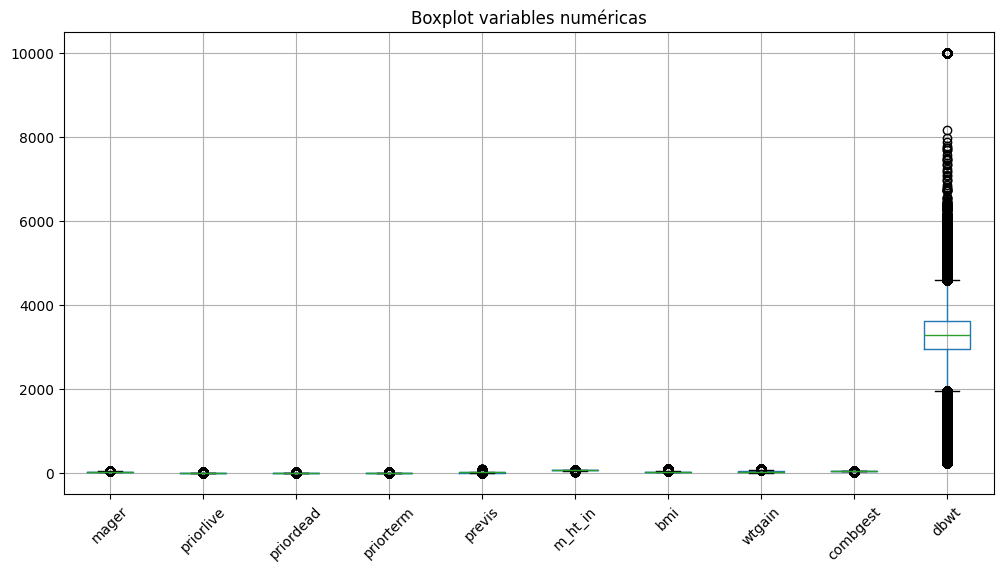

In [20]:
# Visualización de boxplots para variables numéricas

import matplotlib.pyplot as plt

# columnas numéricas reales
num_cols = [
    "mager", "priorlive", "priordead", "priorterm",
    "previs", "m_ht_in", "bmi", "wtgain",
    "combgest", "dbwt"
]

# pasar a pandas (solo estas columnas)
df_pd = df_model.select(*num_cols).toPandas()

# crear boxplots
plt.figure(figsize=(12,6))
df_pd.boxplot()

plt.title("Boxplot variables numéricas")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [21]:
# Capping de outliers (IQR)

from pyspark.sql.functions import col, when

num_cols = [
    "mager", "priorlive", "priordead", "priorterm",
    "previs", "m_ht_in", "bmi", "wtgain",
    "combgest", "dbwt"
]

for c in num_cols:
    # calcular Q1 y Q3
    q1, q3 = df_model.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    print(f"{c} → lower: {lower}, upper: {upper}")

    # aplicar cap
    df_model = df_model.withColumn(
        c,
        when(col(c) < lower, lower)
        .when(col(c) > upper, upper)
        .otherwise(col(c))
    )

mager → lower: 11.5, upper: 47.5
priorlive → lower: -3.0, upper: 5.0
priordead → lower: 0.0, upper: 0.0
priorterm → lower: -1.5, upper: 2.5
previs → lower: 3.0, upper: 19.0
m_ht_in → lower: 56.0, upper: 72.0
bmi → lower: 8.900002500000003, upper: 45.69999849999999
wtgain → lower: -9.5, upper: 66.5
combgest → lower: 35.0, upper: 43.0
dbwt → lower: 1950.0, upper: 4590.0


In [22]:
#reemplazar nulos restantes  por 0 
df_model = df_model.fillna(0)

In [23]:
# Verificar nulos después de limpieza

from pyspark.sql import functions as F

df_model.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_model.columns
]).show(truncate=False)

+------+------+------+------+-----+-----------+--------+------+-------+------+----+-----+-----+---------+---------+---------+-------+------+---+-----+-------+---+------+--------+--------+--------+--------+--------+---------+--------+--------+------+-------+--------+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+------+-------+-------+--------+------+-----+---+------+---+-------+--------+----+--------+--------+-------+-------+-------+-------+------+-------+-------+-------+--------+--------+----+
|dob_mm|dob_tt|dob_wk|bfacil|mager|mbstate_rec|restatus|mrace6|mrace15|mhispx|dmar|meduc|feduc|priorlive|priordead|priorterm|precare|previs|wic|cig_0|m_ht_in|bmi|wtgain|rf_pdiab|rf_gdiab|rf_phype|rf_ghype|rf_ehype|rf_ppterm|rf_inftr|rf_cesar|ip_gon|ip_syph|ip_chlam|ip_hepb|ip_hepc|ob_ecvs|ld_augm|ld_ster|ld_antb|ld_chor|ld_anes|me_pres|me_rout|mm_mtr|mm_plac|mm_rupt|mm_uhyst|attend|mtran|pay|apgar5|sex|dlmp_mm|combgest|dbwt|ab_aven1|ab_aven6|ab_seiz|ca_anen|ca_mn

In [24]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

# columnas numéricas
cols = [c for c, t in df_model.dtypes if t in ("int", "bigint", "double", "float")]



# assembler
assembler = VectorAssembler(
    inputCols=cols,
    outputCol="features"
)

df_vector = assembler.transform(df_model).select("features")

# 🔥 AQUÍ se crea cor_matrix
cor_matrix = Correlation.corr(df_vector, "features").head()[0]

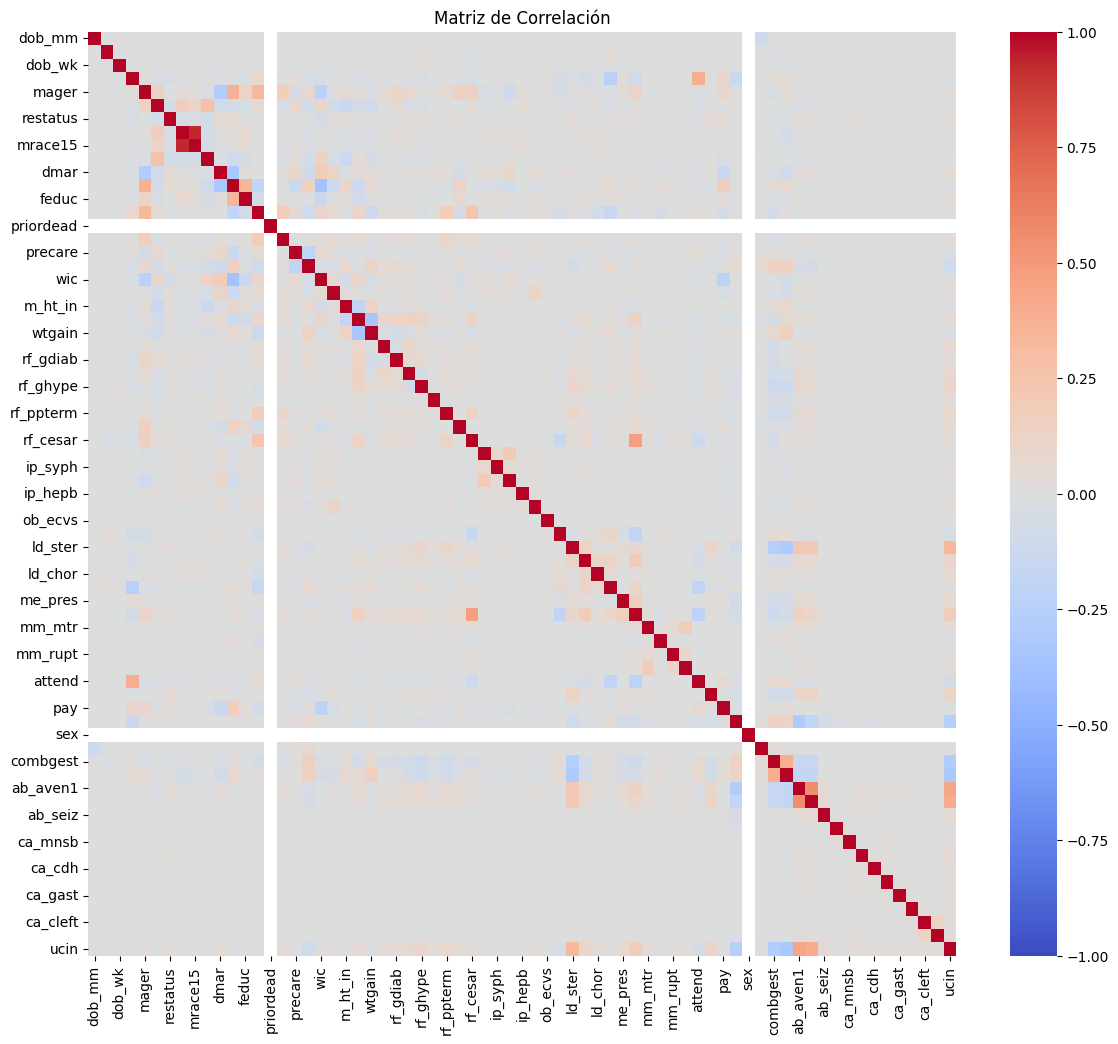

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir DenseMatrix de Spark a array de numpy
corr_array = cor_matrix.toArray()

# Convertir a DataFrame con nombres de columnas
corr_df = pd.DataFrame(corr_array, index=cols, columns=cols)


# Heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de Correlación")
plt.show()

In [28]:
from pyspark.sql.functions import col, round

total = df_model.count()

df_model.groupBy("ucin") \
    .count() \
    .withColumn(
        "porcentaje",
        round((col("count") / total) * 100, 2)
    ) \
    .orderBy("ucin") \
    .show()

+----+-------+----------+
|ucin|  count|porcentaje|
+----+-------+----------+
|   0|3320763|      90.5|
|   1| 348150|       9.5|
+----+-------+----------+



In [29]:

#guardar csv final

df_model.coalesce(1).write.csv(
    "natalidad_preprocesado_ucin",
    header=True,
    mode="overwrite"
)

In [30]:
import os
import shutil

folder = "natalidad_preprocesado_ucin"

csv_file = [f for f in os.listdir(folder) if f.endswith(".csv")][0]

shutil.move(
    os.path.join(folder, csv_file),
    "natalidad_preprocesado_ucin.csv"
)

shutil.rmtree(folder)